# Swarm Systems Lab Simulator Tutorial
This notebook demonstrates how to use the **Swarm Systems Lab Simulator** to simulate simple robot models with controllers. 

## Setup and Imports
First, ensure that the simulator is installed locally for development. You can uncomment the line below if needed.

In [3]:
# Local installation for development
# !pip install -e ..

Now import the standard libraries, third-party libraries, and the simulator modules.

In [3]:
# Standard Libraries
import os

# Third-Party Libraries
import numpy as np
from visualization import PlotBasic

# -------------------------------------------------------------------------------------
# Swarm Systems Lab Simulator Imports
from ssl_simulator import SimulationEngine, load_sim
from ssl_simulator.controllers import ConstantSignal
from ssl_simulator.robot_models import SingleIntegrator, Unicycle2D
from ssl_simulator.visualization import set_paper_parameters

set_paper_parameters(fontsize=12)

# -------------------------------------------------------------------------------------
# Custom plotting functions

# -------------------------------------------------------------------------------------
# Define constants for output file paths
OUTPUT_DIR = os.path.join("..", "output")
SIMDATA_FILE1 = os.path.join(OUTPUT_DIR, "data1.csv")
SIMDATA_FILE2 = os.path.join(OUTPUT_DIR, "data2.csv")

## Exploring the Simulator Module
You can inspect the contents of the `ssl_simulator` module to see available classes, functions and modules.

In [ ]:
import ssl_simulator

dir(ssl_simulator)

## Setting up the logging system

In [4]:
from ssl_simulator.logging import setup_logging
from ssl_simulator.utils import debug_eig

setup_logging(level="DEBUG", format_type="fancy")

A = np.array([[1, 3, 4], [2, 7, 6], [3, 4, 5]])
debug_eig(A)

eigendecomposition
  matrix_shape: [3, 3]
  eigenvalues: shape=(3,) dtype=float64
    [0] +12.4907
    [1]  -0.9395
    [2]  +1.4487
  eigenvectors: shape=(3, 3) dtype=float64
    ┌───────────────────────────┐
    │ -0.3850  -0.8067  +0.2943 │
    │ -0.7412  -0.2133  -0.7484 │
    │ -0.5500  +0.5511  +0.5943 │
    └───────────────────────────┘


In [5]:
from ssl_simulator import setup_logging

setup_logging(level="INFO", format_type="compact")

## Example 1: Single Integrator Controlled by a Constant Signal
We first simulate a simple single integrator robot with a constant control signal.

In [7]:
# ---- Define the initial state
N = 5  # number of robots
p = np.array([np.random.random(N), np.random.random(N)]).T
x0 = [p]

# Controller settings
k = np.array([1, 1])

# ---- Construct the Simulation Engine
dt = 0.01
simulator = SimulationEngine(time_step=dt, log_filename=SIMDATA_FILE1, log_time_step=0.1)

# Add robot model and controller
simulator.set_robot_model(SingleIntegrator, x0)
simulator.add_controller("signal", ConstantSignal, k)

# Connect the controller outputs to the robot inputs
simulator.connect_controller_to_robot(
    "signal", {"u": "u"}
)  # mapping: controller_var -> robot_input

# ---- Run the simulation
tf = 1  # simulation final time
simulator.run(tf)

Running simulation: 100%|██████████| 100/100 [00:00<00:00, 71077.85it/s]


### Inspecting the Simulation Context
You can explore the controllers, robot inputs, and control interfaces in the context for debugging purposes.

In [8]:
simulator.print_controllers()
simulator.print_robot_inputs()
simulator.print_control_interfaces()

[INFO] Controllers in the simulation context:
[INFO]   - Key: 'signal', Controller: ConstantSignal
[INFO]       Output: 'u', Shape: (2,)
[INFO] Robot model 'SingleIntegrator' control inputs:
[INFO]   - Input: 'u', Shape: (2,)
[INFO] Control interfaces in the simulation context:
[INFO]   * Controller 'signal':
[INFO]       - _set_signal(signal)


### Plotting the Simulation Results
We load the saved simulation data and visualize it using the `PlotBasic` class. Setting `debug=True` when loading the simulation provides helpful information about the logged variables and their shapes, which is useful when developing custom visualization functions.

[INFO] time: shape (11,)
[INFO] robot.p: shape (11, 5, 2)
[INFO] robot.p_dot: shape (11, 5, 2)
[INFO] robot.u: shape (11, 2)
[INFO] signal.u: shape (11, 2)
[INFO] signal.k: shape (11, 2)


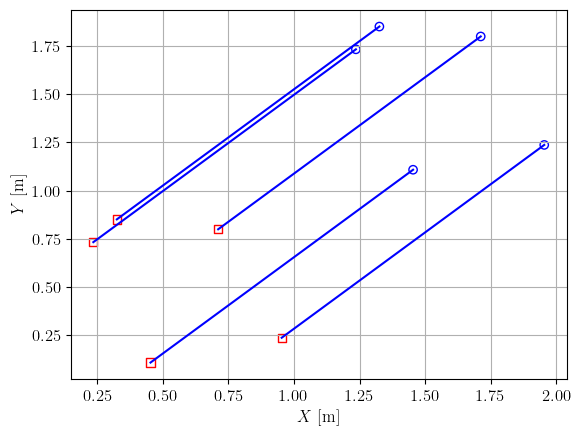

In [9]:
simulation_data, simulation_settings = load_sim(SIMDATA_FILE1)
plotter = PlotBasic(simulation_data)
plotter.plot()

## Example 2: 2D Unicycle Simulation
Next, we simulate multiple 2D unicycle robots with constant angular velocity control.

In [10]:
# ---- Define the initial state
N = 5
p = np.array([np.random.random(N), np.random.random(N)]).T
speed = np.ones(N)
theta = np.random.random(N) * np.pi
x0 = [p, speed, theta]

# ---- Construct the Simulation Engine
dt = 0.01
simulator = SimulationEngine(time_step=dt, log_filename=SIMDATA_FILE2, log_time_step=0.05)

# Add robot model and controllers
simulator.set_robot_model(Unicycle2D, x0)
simulator.add_controller("signal", ConstantSignal, np.pi / 4)
simulator.add_controller("signal_test", ConstantSignal, None)  # example unused controller

# Inspect controllers and robot inputs
simulator.print_controllers()
simulator.print_robot_inputs()

# Connect controller outputs to robot inputs
simulator.connect_controller_to_robot("signal", {"u": "omega"})

# ---- Run the simulation
tf = 1
simulator.run(tf)

[INFO] Controllers in the simulation context:
[INFO]   - Key: 'signal', Controller: ConstantSignal
[INFO]       Output: 'u', Shape: ()
[INFO]   - Key: 'signal_test', Controller: ConstantSignal
[INFO]       Output: 'u', Shape: ()
[INFO] Robot model 'Unicycle2D' control inputs:
[INFO]   - Input: 'omega', Shape: (5,)


Running simulation: 100%|██████████| 100/100 [00:00<00:00, 16075.67it/s]


### Plotting the 2D Unicycle Simulation Results

[INFO] time: shape (21,)
[INFO] robot.p: shape (21, 5, 2)
[INFO] robot.speed: shape (21, 5)
[INFO] robot.theta: shape (21, 5)
[INFO] robot.p_dot: shape (21, 5, 2)
[INFO] robot.speed_dot: shape (21, 5)
[INFO] robot.theta_dot: shape (21, 5)
[INFO] robot.omega: shape (21,)
[INFO] signal.u: shape (21,)
[INFO] signal.k: shape (21,)
[INFO] signal_test.u: shape (21,)
[INFO] signal_test.k: shape (21,)


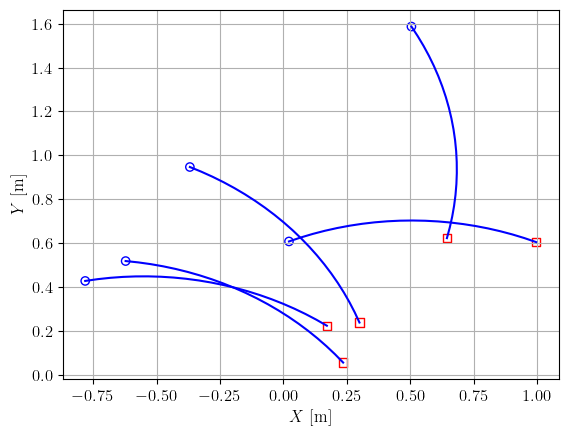

In [11]:
simulation_data, simulation_settings = load_sim(SIMDATA_FILE2, debug=True)
plotter = PlotBasic(simulation_data)
plotter.plot()

# Additional Examples: Oscillatory Motion and High-Level Control
This section demonstrates how to simulate a single integrator following an oscillatory trajectory and how to combine low- and high-level controllers using the controller interface.

## Setup and Imports
Import standard libraries, simulator modules, and custom classes for these examples.

In [12]:
# Local installation for development
# !pip install -e ..

# Standard libraries
import os

import numpy as np
from controllers import DummyOscillatorHL, Oscillator
from visualization import PlotBasic

# Simulator imports
from ssl_simulator import SimulationEngine, load_sim
from ssl_simulator.robot_models import SingleIntegrator
from ssl_simulator.visualization import set_paper_parameters

set_paper_parameters(fontsize=12)

# Custom functions and controllers

# File paths
OUTPUT_DIR = os.path.join("..", "output")
SIMDATA_FILE3 = os.path.join(OUTPUT_DIR, "data3.csv")
SIMDATA_FILE4 = os.path.join(OUTPUT_DIR, "data4.csv")

## Example 1: Single Integrator Following an Oscillatory Motion
This example shows how to use the `Oscillator` controller to make robots follow a sinusoidal trajectory.

In [13]:
# Initial state
N = 5
p = np.ones((N, 2))
x0 = [p]

# Oscillator controller parameters
speed_fixed = 1.4
A_max = 2
omega_fixed = np.pi / 4
speed = np.ones(N) * speed_fixed
A = (np.arange(N) + 1) / (N + 1) * A_max
omega = np.ones(N) * omega_fixed

# Construct the simulator
dt = 0.01
simulator = SimulationEngine(time_step=dt, log_filename=SIMDATA_FILE3)

# Add robot and controller
simulator.set_robot_model(SingleIntegrator, x0)
simulator.add_controller("osc", Oscillator, A, omega, speed)

# Connect the controller to the robot input
simulator.print_controllers()
simulator.print_robot_inputs()
simulator.connect_controller_to_robot("osc", {"u": "u"})

# Run the simulation
tf = 2 * np.pi / np.max(omega)
simulator.run(tf)

[INFO] Controllers in the simulation context:
[INFO]   - Key: 'osc', Controller: Oscillator
[INFO]       Output: 'u', Shape: (5, 2)
[INFO] Robot model 'SingleIntegrator' control inputs:
[INFO]   - Input: 'u', Shape: (5, 2)


Running simulation: 100%|██████████| 800/800 [00:00<00:00, 11736.87it/s]


### Plot the Oscillatory Motion

[INFO] time: shape (801,)
[INFO] robot.p: shape (801, 5, 2)
[INFO] robot.p_dot: shape (801, 5, 2)
[INFO] robot.u: shape (801, 5, 2)
[INFO] osc.u: shape (801, 5, 2)
[INFO] osc.A: shape (801, 5)
[INFO] osc.omega: shape (801, 5)
[INFO] osc.speed: shape (801, 5)
[INFO] osc.gamma: shape (801, 5)


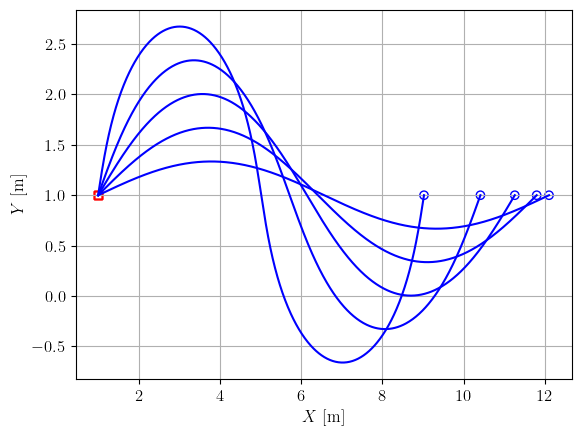

In [14]:
simulation_data, simulation_settings = load_sim(SIMDATA_FILE3, debug=True)
plotter = PlotBasic(simulation_data)
plotter.plot()

## Example 2: Combining Low- and High-Level Control
This example demonstrates using a high-level controller (`DummyOscillatorHL`) to influence the low-level `Oscillator` controller via the controller interface.

In [15]:
# Initial state
N = 2
p = np.ones((N, 2))
x0 = [p]

# Controller settings
speed_fixed = 5
A_max = 2
speed = np.ones(N) * speed_fixed
A = (np.arange(N) + 1) / (N + 1) * A_max
omega = np.zeros(N)

# Construct the simulator
dt = 0.01
simulator = SimulationEngine(time_step=dt, log_filename=SIMDATA_FILE4)

# Add robot model and controllers
simulator.set_robot_model(SingleIntegrator, x0)
simulator.add_controller("osc", Oscillator, A, omega, speed)
simulator.add_controller("osc_hl", DummyOscillatorHL, "osc")

# Connect controller outputs to robot inputs
simulator.print_controllers()
simulator.print_robot_inputs()
simulator.connect_controller_to_robot("osc", {"u": "u"})

# Run the simulation
tf = 5
simulator.run(tf)

[INFO] Controllers in the simulation context:
[INFO]   - Key: 'osc', Controller: Oscillator
[INFO]       Output: 'u', Shape: (2, 2)
[INFO]   - Key: 'osc_hl', Controller: DummyOscillatorHL
[INFO]       Control outputs: None
[INFO] Robot model 'SingleIntegrator' control inputs:
[INFO]   - Input: 'u', Shape: (2, 2)


Running simulation: 100%|██████████| 500/500 [00:00<00:00, 14151.21it/s]


### Plot the High-Level Controlled Oscillator Motion

[INFO] time: shape (501,)
[INFO] robot.p: shape (501, 2, 2)
[INFO] robot.p_dot: shape (501, 2, 2)
[INFO] robot.u: shape (501, 2, 2)
[INFO] osc.u: shape (501, 2, 2)
[INFO] osc.A: shape (501, 2)
[INFO] osc.omega: shape (501, 2)
[INFO] osc.speed: shape (501, 2)
[INFO] osc.gamma: shape (501, 2)


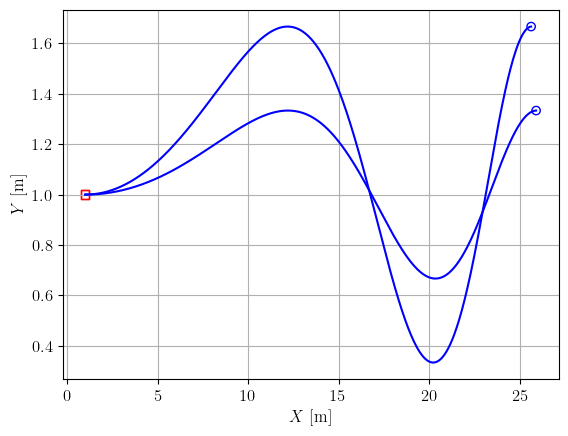

In [16]:
simulation_data, simulation_settings = load_sim(SIMDATA_FILE4, debug=True)
plotter = PlotBasic(simulation_data)
plotter.plot()